In [1]:
import pandas as pd

data = {
    "Имя": ["Анна", "Иван", "Ольга", "Петр", "Мария", "Олег", "Светлана"],
    "Город": ["Москва", "СПб", "Казань", "Москва", "Казань", "СПб", "Казань"],
    "Доход": [50000, 60000, 45000, 70000, 65000, 58000, 47000]
}

df = pd.DataFrame(data)
print(df)

        Имя   Город  Доход
0      Анна  Москва  50000
1      Иван     СПб  60000
2     Ольга  Казань  45000
3      Петр  Москва  70000
4     Мария  Казань  65000
5      Олег     СПб  58000
6  Светлана  Казань  47000


In [2]:
mean_target = df.groupby("Город")["Доход"].mean()
df_encoded = df.copy()
df_encoded["Город"] = df["Город"].map(mean_target)
print(df_encoded)

        Имя         Город  Доход
0      Анна  60000.000000  50000
1      Иван  59000.000000  60000
2     Ольга  52333.333333  45000
3      Петр  60000.000000  70000
4     Мария  52333.333333  65000
5      Олег  59000.000000  58000
6  Светлана  52333.333333  47000


In [16]:
print(df.columns)

Index(['carat', 'cut', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'color_E',
       'color_F', 'color_G', 'color_H', 'color_I', 'color_J'],
      dtype='str')


In [17]:
from sklearn.preprocessing import TargetEncoder

X = df[["cut"]]
y = df["carat"]

encoder = TargetEncoder()
X_encoded = encoder.fit_transform(X, y)

df_encoded = df.copy()
df_encoded["cut"] = X_encoded
print(df_encoded)

          carat       cut  clarity     depth     table         x         y  \
0      1.776201  0.489388        2  2.447919 -0.141333  1.432148  1.378806   
1     -0.127819 -0.185339        3 -0.345564 -0.141333  0.074730  0.128209   
2      1.109794  0.185236        4 -0.435676  0.352009  1.204330  1.187875   
3     -0.580024  0.185236        3  0.645672  1.338693 -0.532787 -0.520956   
4      3.013814  0.050061        1 -2.328036  1.338693  2.495301  2.619857   
...         ...       ...      ...       ...       ...       ...       ...   
49995  2.990014  0.193009        2  0.555560  1.832035  2.248498  2.237995   
49996  0.110184  0.190558        7  0.735784  0.352009  0.274071  0.233221   
49997  0.348186  0.051893        1 -0.345564  2.325377  0.444935  0.529164   
49998  1.157395 -0.182682        1 -0.345564  0.352009  1.147375  1.197422   
49999 -0.127819 -0.179307        6 -0.345564 -1.128017  0.055745  0.109116   

              z  color_E  color_F  color_G  color_H  color_I  c

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Pratik-Bhujade/Diamond-Dataset/refs/heads/master/DiamondData.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.50,Fair,G,SI1,64.5,57.0,10352.0,7.15,7.09,4.59
1,0.70,Ideal,E,VS2,61.4,57.0,2274.0,5.72,5.78,3.53
2,1.22,Premium,G,VS1,61.3,58.0,8779.0,6.91,6.89,4.23
3,0.51,Premium,E,VS2,62.5,60.0,1590.0,5.08,5.10,3.18
4,2.02,Very Good,J,SI2,59.2,60.0,11757.0,8.27,8.39,4.91


In [5]:
df.drop(columns=["price"], inplace=True)
df.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,1.50,Fair,G,SI1,64.5,57.0,7.15,7.09,4.59
1,0.70,Ideal,E,VS2,61.4,57.0,5.72,5.78,3.53
2,1.22,Premium,G,VS1,61.3,58.0,6.91,6.89,4.23
3,0.51,Premium,E,VS2,62.5,60.0,5.08,5.10,3.18
4,2.02,Very Good,J,SI2,59.2,60.0,8.27,8.39,4.91


In [6]:
df.isna().sum()

carat        0
cut          0
color        0
clarity      0
depth      471
table      390
x          221
y          333
z          428
dtype: int64

<Axes: >

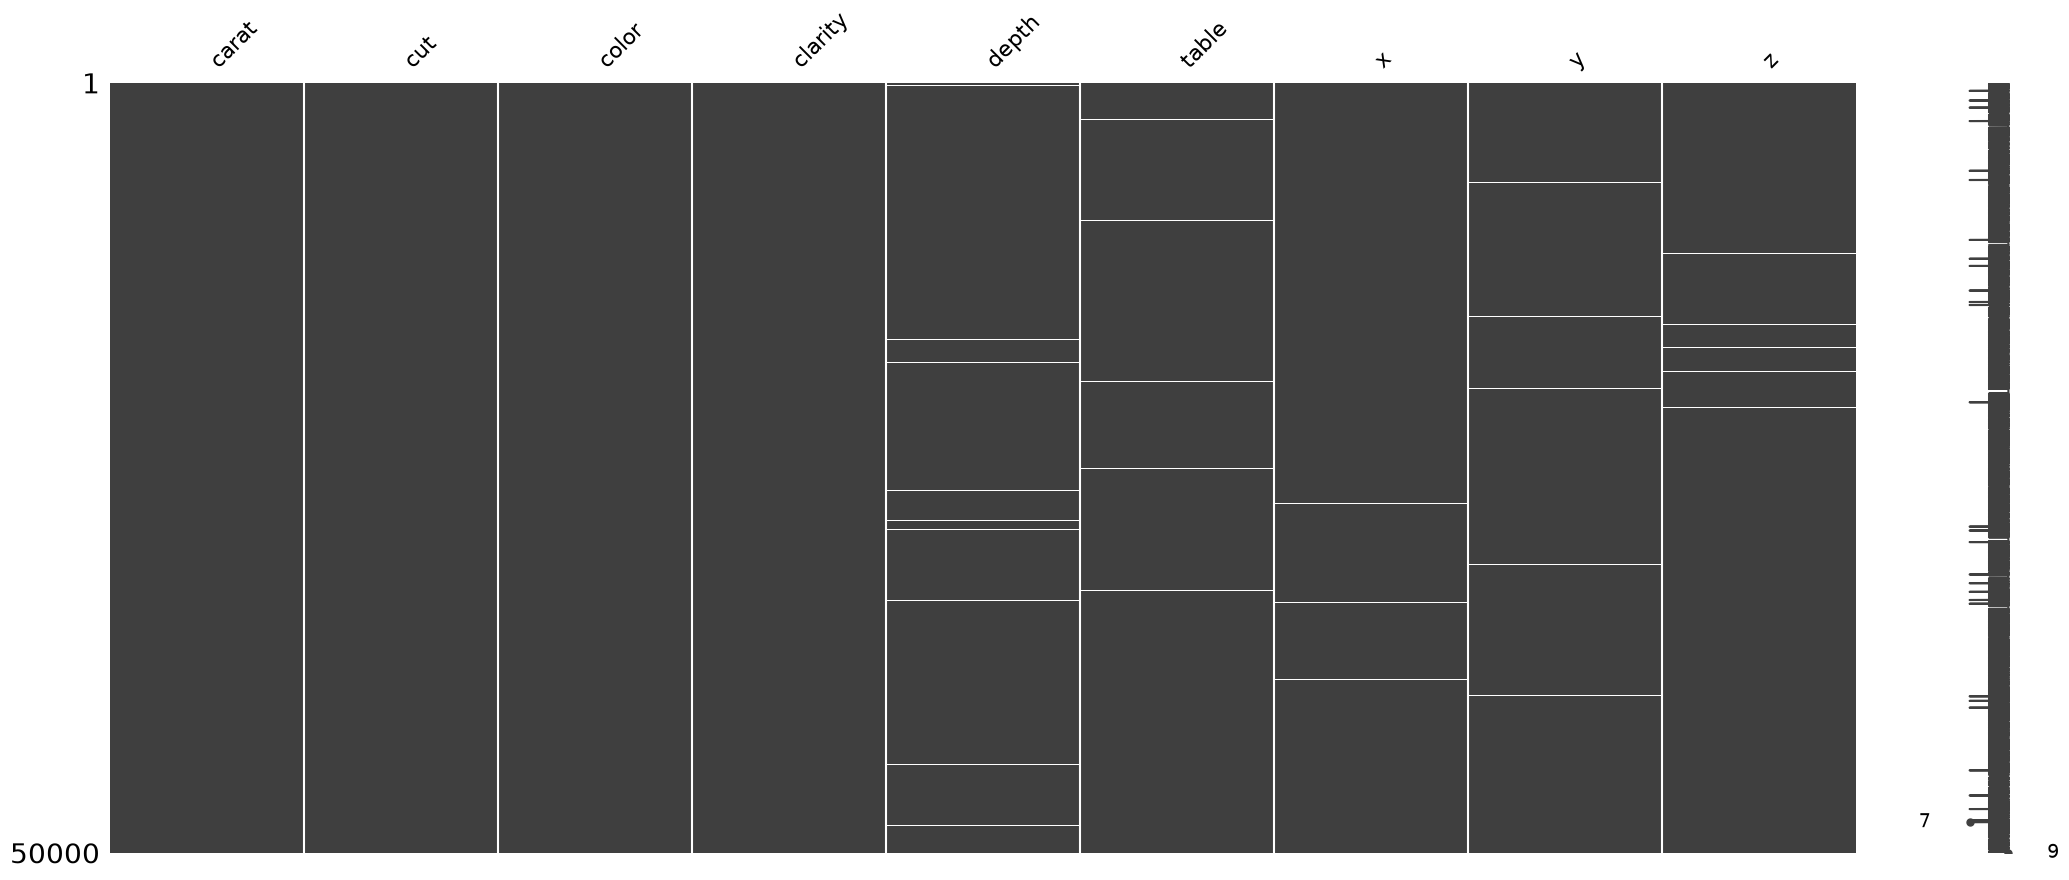

In [7]:
import missingno as msno
msno.matrix(df)

In [8]:
df = df.dropna()
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

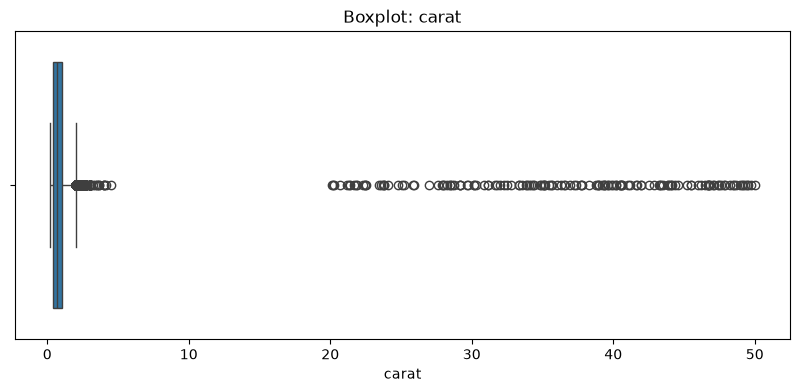

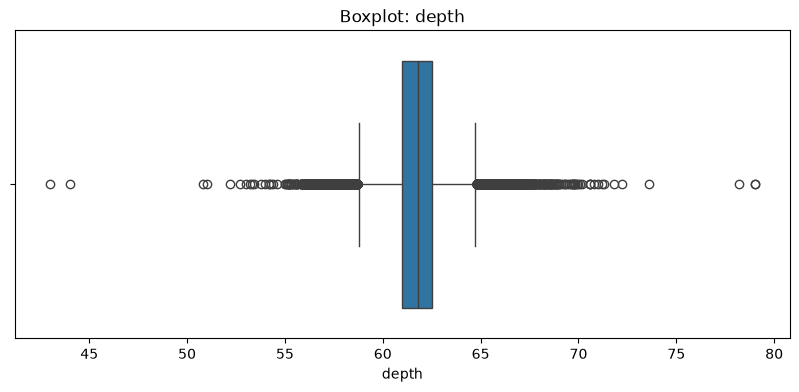

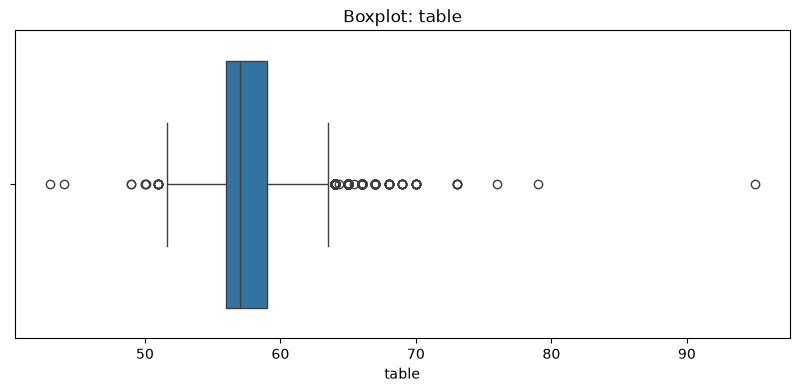

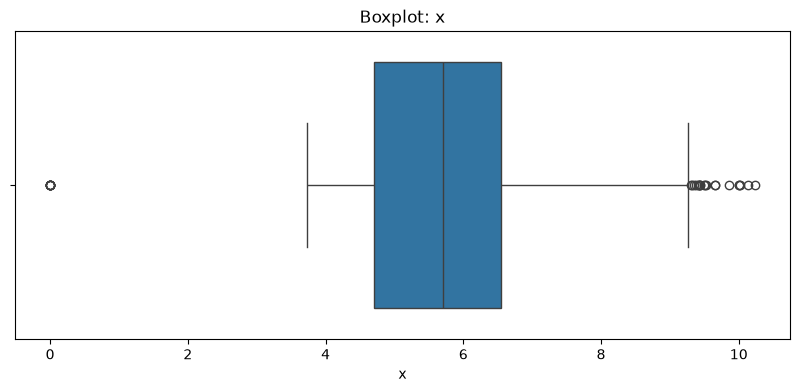

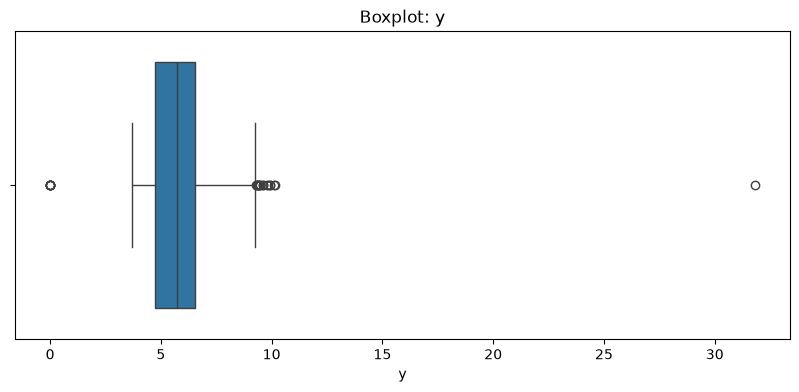

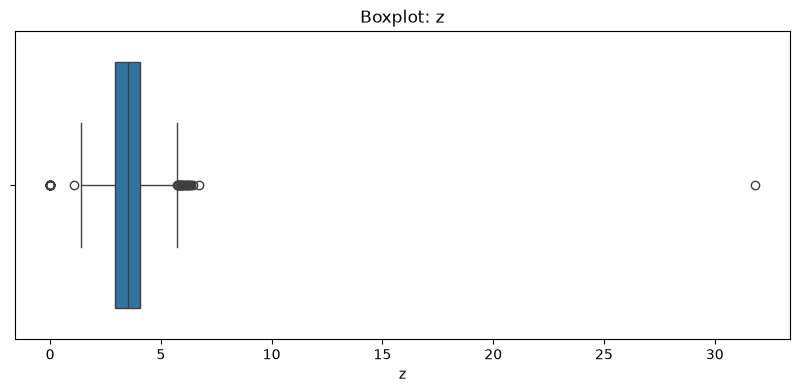

In [9]:
import seaborn as sns

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [11]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

for col in ["carat", "depth", "table", "x", "y", "z"]:
    df = remove_outliers_iqr(df, col)

df.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,1.50,Fair,G,SI1,64.5,57.0,7.15,7.09,4.59
1,0.70,Ideal,E,VS2,61.4,57.0,5.72,5.78,3.53
2,1.22,Premium,G,VS1,61.3,58.0,6.91,6.89,4.23
3,0.51,Premium,E,VS2,62.5,60.0,5.08,5.10,3.18
4,2.02,Very Good,J,SI2,59.2,60.0,8.27,8.39,4.91


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,1.776201,Fair,G,SI1,2.447919,-0.141333,1.432148,1.378806,1.695091
1,-0.127819,Ideal,E,VS2,-0.345564,-0.141333,0.074730,0.128209,0.066886
2,1.109794,Premium,G,VS1,-0.435676,0.352009,1.204330,1.187875,1.142116
3,-0.580024,Premium,E,VS2,0.645672,1.338693,-0.532787,-0.520956,-0.470728
4,3.013814,Very Good,J,SI2,-2.328036,1.338693,2.495301,2.619857,2.186624


In [13]:
cut_mapping = {
    "Fair": 0, "Good": 1, "Very Good": 2, "Premium": 3, "Ideal": 4
}

df["cut"] = df["cut"].map(cut_mapping)

clarity_mapping = {
    "I1": 0, "SI2": 1, "SI1": 2, "VS2": 3,
    "VS1": 4, "VVS2": 5, "VVS1": 6, "IF": 7
}

df["clarity"] = df["clarity"].map(clarity_mapping)

df.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,1.776201,0.0,G,2,2.447919,-0.141333,1.432148,1.378806,1.695091
1,-0.127819,4.0,E,3,-0.345564,-0.141333,0.074730,0.128209,0.066886
2,1.109794,3.0,G,4,-0.435676,0.352009,1.204330,1.187875,1.142116
3,-0.580024,3.0,E,3,0.645672,1.338693,-0.532787,-0.520956,-0.470728
4,3.013814,2.0,J,1,-2.328036,1.338693,2.495301,2.619857,2.186624


In [14]:
df = pd.get_dummies(df, columns=["color"], drop_first=True)
print(df.head())

      carat  cut  clarity     depth     table         x         y         z  \
0  1.776201  0.0        2  2.447919 -0.141333  1.432148  1.378806  1.695091   
1 -0.127819  4.0        3 -0.345564 -0.141333  0.074730  0.128209  0.066886   
2  1.109794  3.0        4 -0.435676  0.352009  1.204330  1.187875  1.142116   
3 -0.580024  3.0        3  0.645672  1.338693 -0.532787 -0.520956 -0.470728   
4  3.013814  2.0        1 -2.328036  1.338693  2.495301  2.619857  2.186624   

   color_E  color_F  color_G  color_H  color_I  color_J  
0    False    False     True    False    False    False  
1     True    False    False    False    False    False  
2    False    False     True    False    False    False  
3     True    False    False    False    False    False  
4    False    False    False    False    False     True  
